<Axes: >

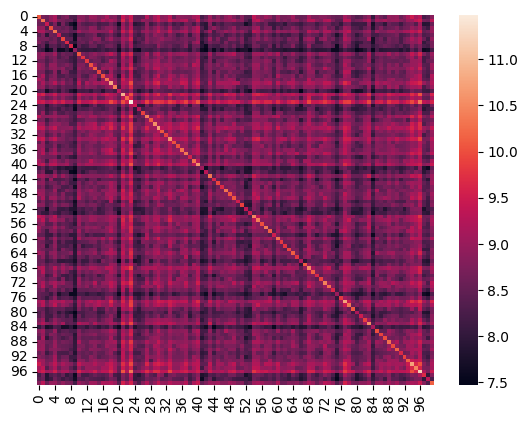

In [1]:
import numpy as np
import seaborn as sns

p = 100
cov = np.random.rand(p,p)
cov = np.sqrt(cov.T@cov)
cov /= np.trace(cov)/p
cov *=10
sns.heatmap(cov)



In [2]:
n_classes = 10
n_per_class =1000
X = []
y = []
for ci in range(n_classes):
    mean_c = np.random.rand(p)
    X.append(np.random.multivariate_normal(mean_c, cov, size=n_per_class))
    y.append(np.ones(n_per_class)*ci)
X = np.vstack(X)
y = np.hstack(y)

/tmp/ipykernel_8464/80746510.py:7: RuntimeWarning: covariance is not positive-semidefinite.
  X.append(np.random.multivariate_normal(mean_c, cov, size=n_per_class))


<Axes: xlabel='0', ylabel='1'>

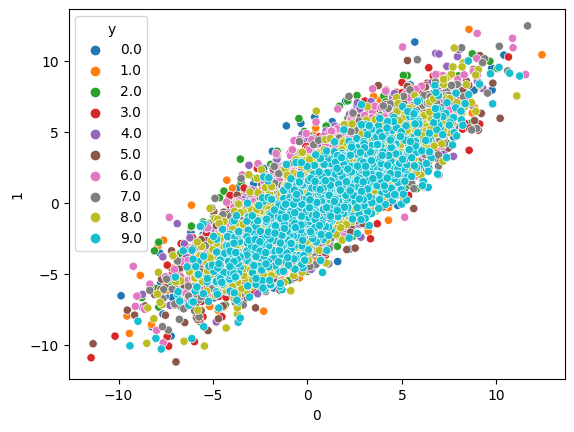

In [3]:
import pandas as pd
df = pd.DataFrame(X)
df['y'] = y
sns.scatterplot(data=df, x=0, y=1, hue='y', palette='tab10')

<Axes: >

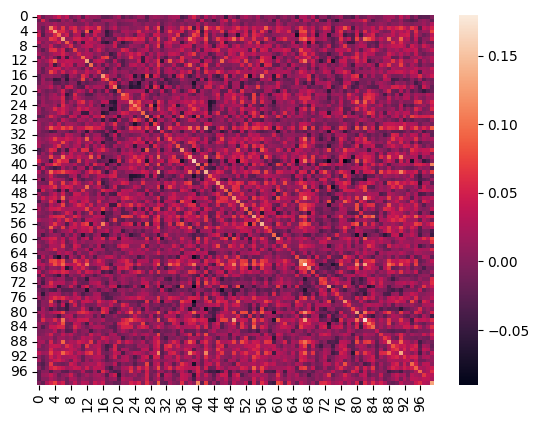

In [4]:
# Determine between class scatter
n = X.shape[0]
classes = np.unique(y)
n_classes = len(classes)
class_means = np.zeros((n_classes,p))
for ci, c in enumerate(classes):
    class_means[ci] = np.mean(X[y==c], axis=0)
mean = np.mean(class_means, axis=0)
scatter_B = 0
for ci, c in enumerate(classes):
    n_class = np.count_nonzero(y==c)
    scatter_B += n_class*np.outer((class_means[ci]-mean),(class_means[ci]-mean))
scatter_B /= n
sns.heatmap(scatter_B)

<Axes: >

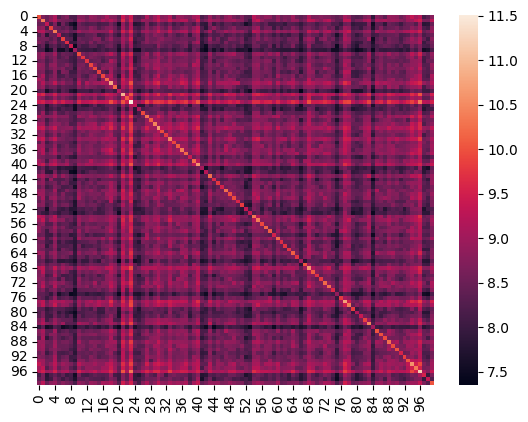

In [5]:
# Determine whithin class scatter
scatter_W = 0
X_c = X.copy()
for ci, c in enumerate(classes):
    X_c[y==c] -= class_means[ci]
scatter_W = X_c.T@X_c
scatter_W /= n
sns.heatmap(scatter_W)

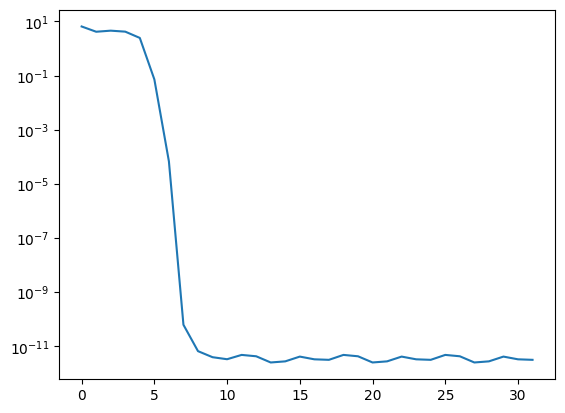

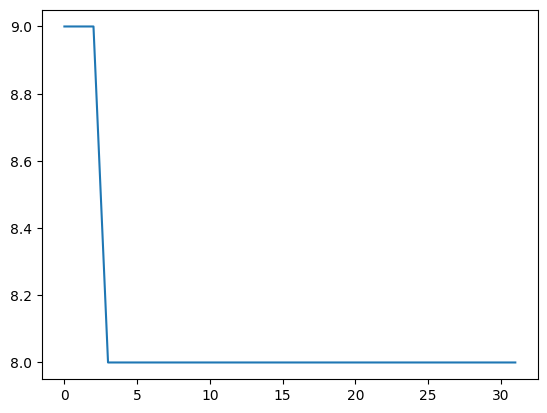

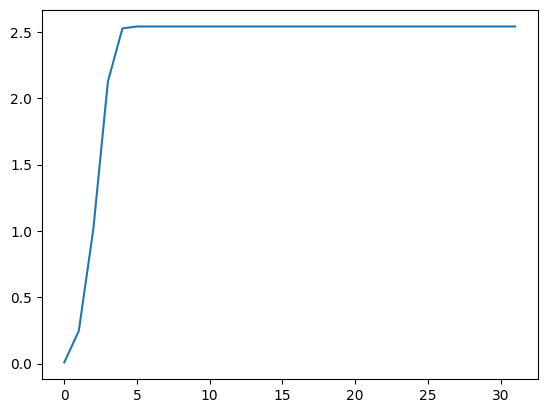

In [6]:
import scipy.linalg
import matplotlib.pyplot as plt

k=20
v = np.zeros((p,k))
v[:k,:k] = np.eye(k)

updates = []
k_opt = []
tr = []


last_v = v
for i in range(32):
    phi = np.trace(v.T@scatter_B@v)/np.trace(v.T@scatter_W@v)
    tr.append(phi)
    w,v = scipy.linalg.eig(scatter_B-phi*scatter_W)
    k_opt.append(np.count_nonzero(w>0))
    idc = np.argsort(-w)
    w = w[idc]
    v = v[:,idc]
    w = w[:k]
    v = v[:,:k]
    sign = np.sign(v[0,:])
    v = v*sign
    v, _ = np.linalg.qr(v, mode="reduced")
    updates.append(np.linalg.norm(v-last_v))
    last_v = v.copy()


plt.semilogy(updates)
plt.show()
plt.plot(k_opt)
plt.show()
plt.plot(tr)

In [7]:
Xt = X@v
Xt.shape

(10000, 20)

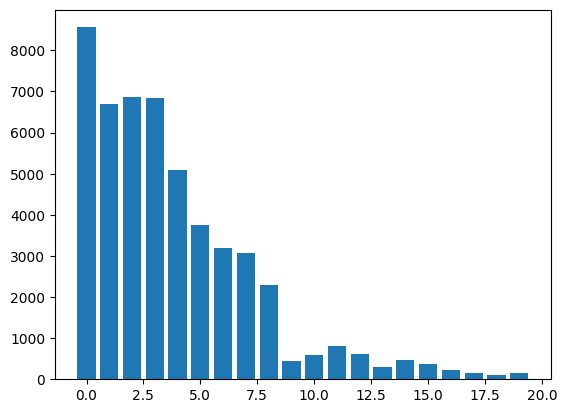

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 6.41611341e-254, 1.86722412e-201, 2.96664283e-269])

In [8]:
F ,p= scipy.stats.f_oneway(*[Xt[y==c] for c in classes])
plt.bar(np.arange(F.shape[0]), F)
plt.show()
p

<Axes: xlabel='0', ylabel='1'>

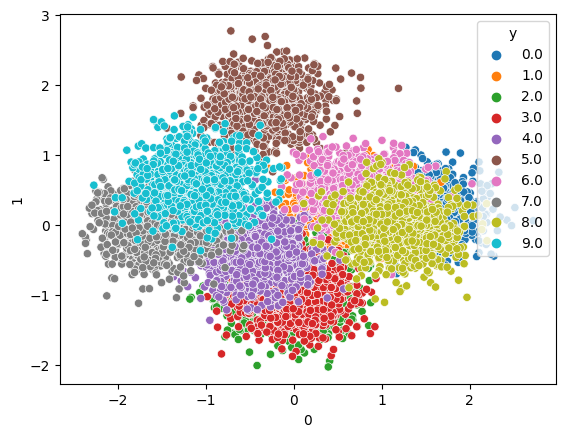

In [9]:
import pandas as pd
dft = pd.DataFrame(Xt)
dft['y'] = y
sns.scatterplot(data=dft, x=0, y=1, hue='y', palette='tab10')